  Hover power (model)  : 451.9 W
  Hover power (doc)    : 451.9 W  ✓
  Max-endurance speed  : 14.90 m/s  |  208.1 W
  Optimal cruise speed : 15.00 m/s  |  208.2 W
  Endurance @ Vend     : 23.2 min
  Doc endurance @80%   : 10.2 min
  Range @ Vopt         : 20.89 km

  Optimal altitude : 49.1 m
  Swath width      : 75.3 m
  Track spacing    : 60.3 m
  Passes           : 1
  Mission energy   : 0.76 Wh  (avail: 80.5 Wh)
  Mission time     : 0.18 min
  Turn radius      : 20.25 m


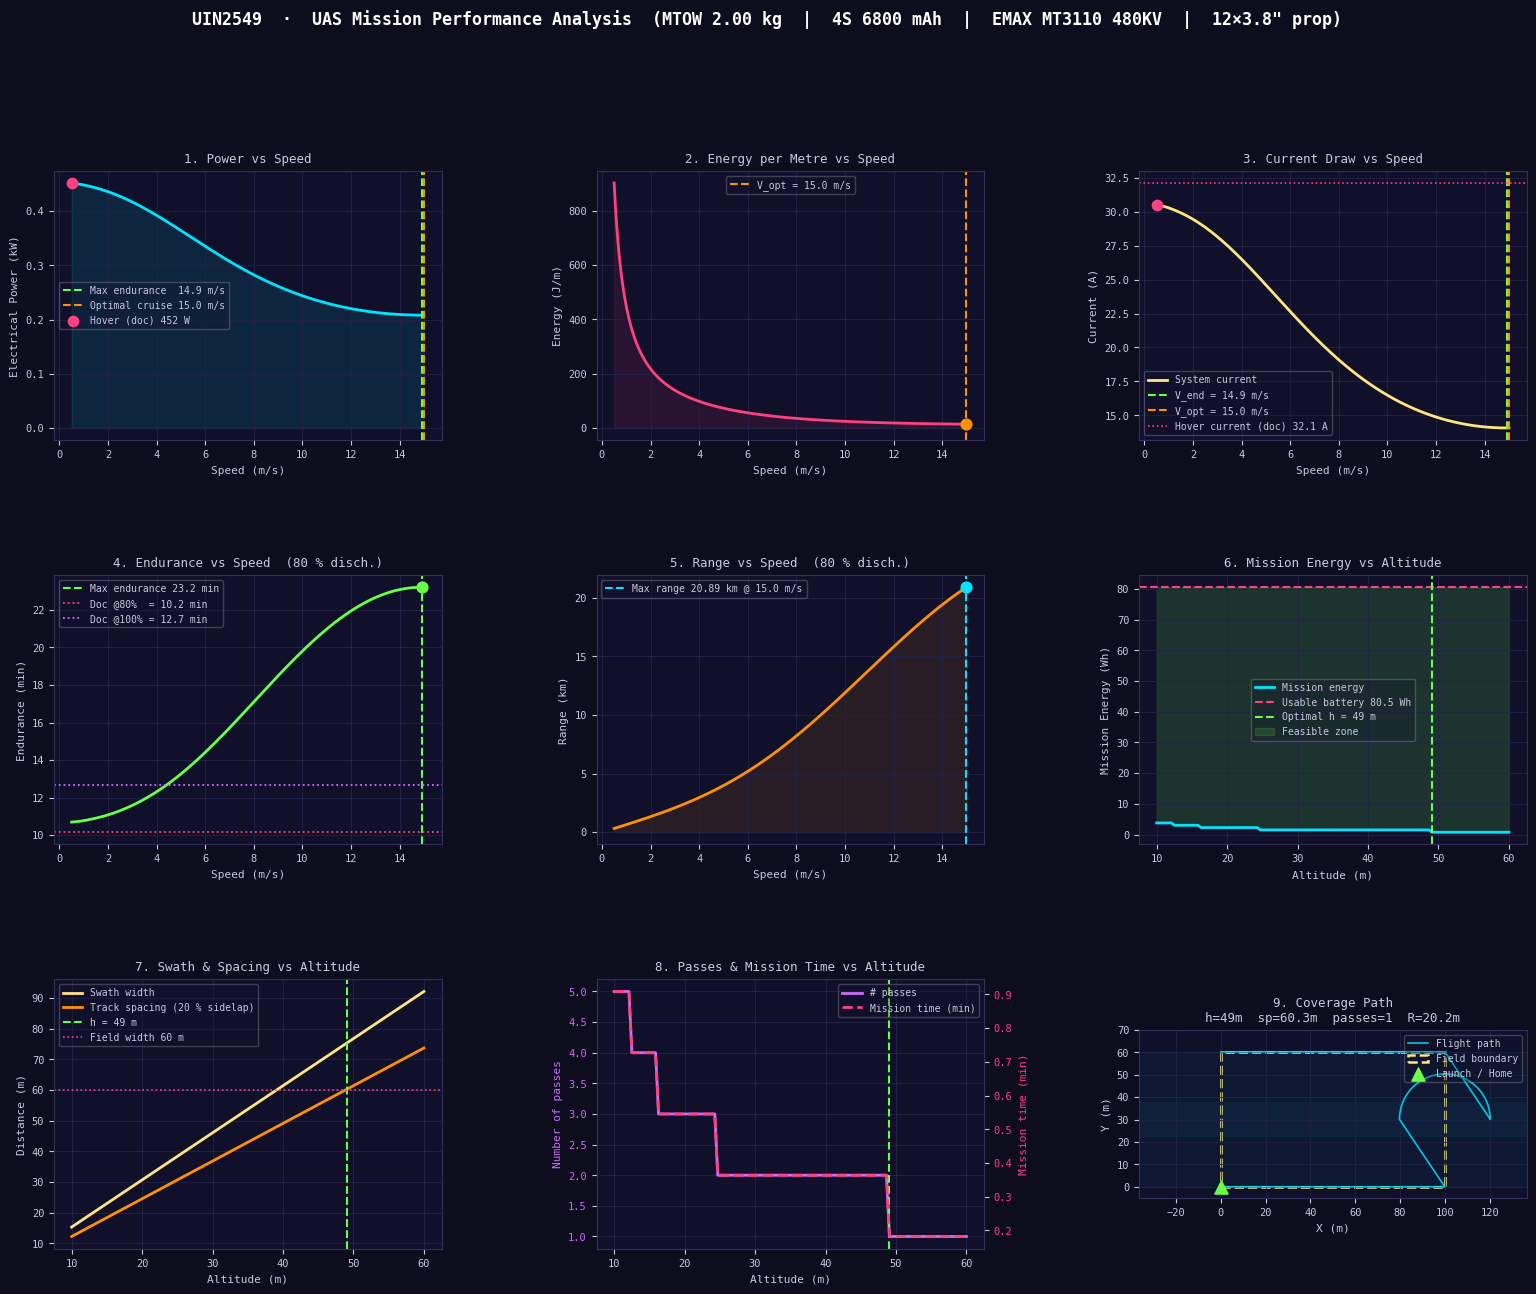


Saved → /mnt/user-data/outputs/uas_mission_analysis.png


In [1]:
"""
UIN2549 — UAS Mission Performance Analysis
Calibrated against document-measured values:
  - Hover power: 451.91 W (total system, 32.128 A @ 14.8 V)
  - Endurance @80% disch: 10.15 min
  - Max thrust per motor: 1020 gf = 10.0 N
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────────────────
# 1.  DESIGN CONSTANTS  (all from UIN2549 document)
# ─────────────────────────────────────────────────────────
rotors   = 4
m_total  = 1.995          # kg  (total with payload, doc: 1995 g)
payload  = 0.200          # kg
prop_r   = 0.1524         # m   12-inch prop  (0.3048 / 2)
rho      = 1.225          # kg/m³
g        = 9.81           # m/s²
W        = m_total * g    # N  = 19.57 N

# Battery (doc)
V_batt   = 14.8           # V
Q_batt   = 6.8            # Ah
Wh_total = V_batt * Q_batt  # 100.6 Wh
Wh_80    = 0.80 * Wh_total  # 80.5 Wh  (80 % depth of discharge)

# Thrust limits (doc: 1020 gf per motor = 10.0 N)
T_max_motor = 10.0        # N per motor
T_max_total = rotors * T_max_motor   # 40 N
theta_max   = np.arccos(W / T_max_total)   # ≈ 60.7°

# Document-measured hover power (total system, table 1.6.1)
P_hover_doc = 451.91      # W   (32.128 A × 14.8 V)

# ─────────────────────────────────────────────────────────
# 2.  POWER MODEL
#
#  We use momentum theory for the SHAPE of the power curve,
#  then apply a calibration factor so that P(0) = P_hover_doc.
#  This is honest: small props deviate from ideal theory, and
#  the document gives us a measured reference point.
# ─────────────────────────────────────────────────────────
A_disk = rotors * np.pi * prop_r**2   # 0.293 m²
v_h    = np.sqrt(W / (2 * rho * A_disk))   # hover induced velocity ≈ 5.23 m/s

CdA_body = 0.025   # m²  body parasitic drag area

def power_model(V):
    """
    Electrical power [W] at forward speed V [m/s].
    Glauert forward-flight induced power + parasite drag power.
    Calibrated so P(0) == P_hover_doc.
    """
    # Induced velocity (Glauert iterative)
    vi = v_h
    for _ in range(60):
        V_eff  = np.sqrt(V**2 + vi**2)
        vi_new = v_h**2 / V_eff
        if abs(vi_new - vi) < 1e-8:
            break
        vi = vi_new

    # Ideal induced + parasite
    P_induced_ideal = W * vi
    P_parasite      = 0.5 * rho * CdA_body * V**2 * V   # D*V

    # Calibration: match hover point to measured value
    # At V=0: P_induced_ideal = W * v_h
    calib = P_hover_doc / (W * v_h)   # ≈ 4.41

    return calib * P_induced_ideal + P_parasite

# ─────────────────────────────────────────────────────────
# 3.  SPEED SWEEP
# ─────────────────────────────────────────────────────────
V_range  = np.linspace(0.5, 15, 300)
P_vals   = np.array([power_model(v) for v in V_range])
EPM      = P_vals / V_range          # J/m  energy per metre
I_vals   = P_vals / V_batt           # A

idx_end  = np.argmin(P_vals)
V_end    = V_range[idx_end]
P_end    = P_vals[idx_end]

idx_opt  = np.argmin(EPM)
V_opt    = V_range[idx_opt]
P_opt    = P_vals[idx_opt]

# ─────────────────────────────────────────────────────────
# 4.  ENDURANCE & RANGE
# ─────────────────────────────────────────────────────────
endurance_min = (Wh_80 / P_vals) * 60       # minutes
range_km      = (Wh_80 * 3600 / P_vals) * V_range / 1000

end_at_Vend  = (Wh_80 / P_end)  * 60
range_at_Vopt = (Wh_80 * 3600 / P_opt) * V_opt / 1000

# Document validation (exact formula from doc)
end_doc_80  = (6.8 * 0.8 * 60) / 32.128   # 10.15 min
end_doc_100 = (6.8 * 1.0 * 60) / 32.128   # 12.70 min

print("=" * 50)
print(f"  Hover power (model)  : {power_model(0.01):.1f} W")
print(f"  Hover power (doc)    : {P_hover_doc:.1f} W  ✓")
print(f"  Max-endurance speed  : {V_end:.2f} m/s  |  {P_end:.1f} W")
print(f"  Optimal cruise speed : {V_opt:.2f} m/s  |  {P_opt:.1f} W")
print(f"  Endurance @ Vend     : {end_at_Vend:.1f} min")
print(f"  Doc endurance @80%   : {end_doc_80:.1f} min")
print(f"  Range @ Vopt         : {range_at_Vopt:.2f} km")
print("=" * 50)

# ─────────────────────────────────────────────────────────
# 5.  TURN RADIUS
# ─────────────────────────────────────────────────────────
theta_safe = 0.80 * theta_max
R_turn     = V_opt**2 / (g * np.tan(theta_safe))

# ─────────────────────────────────────────────────────────
# 6.  COVERAGE MISSION
# ─────────────────────────────────────────────────────────
fov_deg  = 75.0    # RPi Cam 3 — doc states 75°
sidelap  = 0.20    # doc: 20 % image overlap
field_L  = 100.0   # m
field_W  = 60.0    # m

def swath(h):
    return 2 * h * np.tan(np.radians(fov_deg / 2))

def spacing(h):
    return swath(h) * (1 - sidelap)

def mission_energy(h, V, R, P):
    sp     = spacing(h)
    passes = max(1, int(np.ceil(field_W / sp)))
    s_str  = passes * field_L
    s_turn = passes * np.pi * R
    P_turn = P / np.cos(theta_safe)   # extra power in banked turn
    t_str  = s_str  / V
    t_turn = s_turn / V
    E_J    = P * t_str + P_turn * t_turn
    return E_J / 3600, (t_str + t_turn), passes, sp

altitudes = np.linspace(10, 60, 120)
mis_energy = []
mis_time   = []
mis_passes = []
mis_sp     = []
mis_swath  = []

for h in altitudes:
    e, t, pa, sp = mission_energy(h, V_opt, R_turn, P_opt)
    mis_energy.append(e)
    mis_time.append(t)
    mis_passes.append(pa)
    mis_sp.append(sp)
    mis_swath.append(swath(h))

mis_energy = np.array(mis_energy)
mis_time   = np.array(mis_time)
mis_passes = np.array(mis_passes)
mis_sp     = np.array(mis_sp)
mis_swath  = np.array(mis_swath)

feasible   = mis_energy <= Wh_80
idx_best   = np.argmin(mis_energy[feasible]) if feasible.any() else np.argmin(mis_energy)
h_best     = altitudes[feasible][idx_best] if feasible.any() else altitudes[np.argmin(mis_energy)]
e_best, t_best, pa_best, sp_best = mission_energy(h_best, V_opt, R_turn, P_opt)

print(f"\n  Optimal altitude : {h_best:.1f} m")
print(f"  Swath width      : {swath(h_best):.1f} m")
print(f"  Track spacing    : {sp_best:.1f} m")
print(f"  Passes           : {pa_best}")
print(f"  Mission energy   : {e_best:.2f} Wh  (avail: {Wh_80:.1f} Wh)")
print(f"  Mission time     : {t_best/60:.2f} min")
print(f"  Turn radius      : {R_turn:.2f} m")

# ─────────────────────────────────────────────────────────
# 7.  PATH GENERATOR
# ─────────────────────────────────────────────────────────
def generate_path(L, W_f, sp, R):
    x, y = [], []
    direction = 1
    y_pos = 0.0
    y_passes = []

    while y_pos <= W_f + sp * 0.5:
        y_passes.append(y_pos)
        x_leg = np.linspace(0, L, 200) if direction == 1 else np.linspace(L, 0, 200)
        x.extend(x_leg)
        y.extend(np.ones(200) * y_pos)

        next_y = y_pos + sp
        if next_y > W_f + sp * 0.5:
            break

        # Semicircle turn
        xc    = L if direction == 1 else 0
        yc    = y_pos + sp / 2
        sgn   = 1 if direction == 1 else -1
        theta = np.linspace(np.pi, 0, 60) if direction == 1 else np.linspace(0, np.pi, 60)
        x.extend(xc + sgn * R * np.cos(theta))
        y.extend(yc + R * np.sin(theta))

        y_pos     += sp
        direction *= -1

    return np.array(x), np.array(y)

x_path, y_path = generate_path(field_L, field_W, sp_best, R_turn)

# ─────────────────────────────────────────────────────────
# 8.  PLOTS
# ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "#0d0d1e",
    "axes.facecolor"   : "#10102a",
    "axes.edgecolor"   : "#30305a",
    "axes.labelcolor"  : "#c8c8e0",
    "xtick.color"      : "#c8c8e0",
    "ytick.color"      : "#c8c8e0",
    "text.color"       : "#c8c8e0",
    "grid.color"       : "#22224a",
    "grid.linewidth"   : 0.6,
    "font.family"      : "monospace",
    "axes.titlesize"   : 9,
    "axes.labelsize"   : 8,
    "xtick.labelsize"  : 7.5,
    "ytick.labelsize"  : 7.5,
    "legend.fontsize"  : 7,
    "legend.framealpha": 0.25,
})

CYAN   = "#00e5ff"
GREEN  = "#69ff47"
ORANGE = "#ff9100"
PINK   = "#ff4081"
YELLOW = "#ffe57f"
WHITE  = "#ffffff"
PURPLE = "#cf6bff"

fig = plt.figure(figsize=(19, 14))
fig.patch.set_facecolor("#0d0d1e")
fig.suptitle(
    "UIN2549  ·  UAS Mission Performance Analysis  "
    f"(MTOW {m_total:.2f} kg  |  4S 6800 mAh  |  EMAX MT3110 480KV  |  12×3.8\" prop)",
    fontsize=12, color=WHITE, fontweight="bold", y=0.995
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.40)

# ── 1. Power vs Speed ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(V_range, P_vals / 1000, color=CYAN, lw=2)
ax1.axvline(V_end, color=GREEN,  lw=1.5, ls="--", label=f"Max endurance  {V_end:.1f} m/s")
ax1.axvline(V_opt, color=ORANGE, lw=1.5, ls="--", label=f"Optimal cruise {V_opt:.1f} m/s")
ax1.fill_between(V_range, P_vals / 1000, alpha=0.10, color=CYAN)
ax1.scatter([0.5], [P_hover_doc / 1000], color=PINK, s=55, zorder=6,
            label=f"Hover (doc) {P_hover_doc:.0f} W")
ax1.set_title("1. Power vs Speed")
ax1.set_xlabel("Speed (m/s)")
ax1.set_ylabel("Electrical Power (kW)")
ax1.legend()
ax1.grid(True)

# ── 2. Energy per Metre vs Speed ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(V_range, EPM, color=PINK, lw=2)
ax2.axvline(V_opt, color=ORANGE, lw=1.5, ls="--", label=f"V_opt = {V_opt:.1f} m/s")
ax2.scatter([V_opt], [EPM[idx_opt]], color=ORANGE, s=60, zorder=6)
ax2.fill_between(V_range, EPM, alpha=0.10, color=PINK)
ax2.set_title("2. Energy per Metre vs Speed")
ax2.set_xlabel("Speed (m/s)")
ax2.set_ylabel("Energy (J/m)")
ax2.legend()
ax2.grid(True)

# ── 3. Current Draw vs Speed ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(V_range, I_vals, color=YELLOW, lw=2, label="System current")
ax3.axvline(V_end, color=GREEN,  lw=1.5, ls="--", label=f"V_end = {V_end:.1f} m/s")
ax3.axvline(V_opt, color=ORANGE, lw=1.5, ls="--", label=f"V_opt = {V_opt:.1f} m/s")
ax3.axhline(32.128, color=PINK, lw=1.2, ls=":", label="Hover current (doc) 32.1 A")
ax3.scatter([0.5], [P_hover_doc / V_batt], color=PINK, s=55, zorder=6)
ax3.set_title("3. Current Draw vs Speed")
ax3.set_xlabel("Speed (m/s)")
ax3.set_ylabel("Current (A)")
ax3.legend()
ax3.grid(True)

# ── 4. Endurance vs Speed ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(V_range, endurance_min, color=GREEN, lw=2)
ax4.axvline(V_end, color=GREEN,  lw=1.5, ls="--", label=f"Max endurance {end_at_Vend:.1f} min")
ax4.axhline(end_doc_80,  color=PINK,   lw=1.3, ls=":", label=f"Doc @80%  = {end_doc_80:.1f} min")
ax4.axhline(end_doc_100, color=PURPLE, lw=1.3, ls=":", label=f"Doc @100% = {end_doc_100:.1f} min")
ax4.scatter([V_end], [end_at_Vend], color=GREEN, s=60, zorder=6)
ax4.set_title("4. Endurance vs Speed  (80 % disch.)")
ax4.set_xlabel("Speed (m/s)")
ax4.set_ylabel("Endurance (min)")
ax4.legend()
ax4.grid(True)

# ── 5. Range vs Speed ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(V_range, range_km, color=ORANGE, lw=2)
ax5.axvline(V_opt, color=CYAN, lw=1.5, ls="--", label=f"Max range {range_at_Vopt:.2f} km @ {V_opt:.1f} m/s")
ax5.scatter([V_opt], [range_at_Vopt], color=CYAN, s=60, zorder=6)
ax5.fill_between(V_range, range_km, alpha=0.10, color=ORANGE)
ax5.set_title("5. Range vs Speed  (80 % disch.)")
ax5.set_xlabel("Speed (m/s)")
ax5.set_ylabel("Range (km)")
ax5.legend()
ax5.grid(True)

# ── 6. Mission Energy vs Altitude ────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(altitudes, mis_energy, color=CYAN, lw=2, label="Mission energy")
ax6.axhline(Wh_80, color=PINK,  lw=1.5, ls="--", label=f"Usable battery {Wh_80:.1f} Wh")
ax6.axvline(h_best, color=GREEN, lw=1.5, ls="--", label=f"Optimal h = {h_best:.0f} m")
ax6.fill_between(altitudes, mis_energy, Wh_80,
                 where=mis_energy <= Wh_80,
                 alpha=0.15, color=GREEN, label="Feasible zone")
ax6.set_title("6. Mission Energy vs Altitude")
ax6.set_xlabel("Altitude (m)")
ax6.set_ylabel("Mission Energy (Wh)")
ax6.legend()
ax6.grid(True)

# ── 7. Swath & Spacing vs Altitude ──────────────────────
ax7 = fig.add_subplot(gs[2, 0])
ax7.plot(altitudes, mis_swath, color=YELLOW, lw=2, label="Swath width")
ax7.plot(altitudes, mis_sp,    color=ORANGE, lw=2, label=f"Track spacing (20 % sidelap)")
ax7.axvline(h_best, color=GREEN,  lw=1.5, ls="--", label=f"h = {h_best:.0f} m")
ax7.axhline(field_W, color=PINK,  lw=1.2, ls=":", label=f"Field width {field_W:.0f} m")
ax7.set_title("7. Swath & Spacing vs Altitude")
ax7.set_xlabel("Altitude (m)")
ax7.set_ylabel("Distance (m)")
ax7.legend()
ax7.grid(True)

# ── 8. Pass Count & Mission Time vs Altitude ────────────
ax8 = fig.add_subplot(gs[2, 1])
color_pass = PURPLE
color_time = PINK
ax8_r = ax8.twinx()
ax8.plot(altitudes, mis_passes, color=color_pass, lw=2, label="# passes")
ax8_r.plot(altitudes, mis_time / 60, color=color_time, lw=2, ls="--", label="Mission time (min)")
ax8.axvline(h_best, color=GREEN, lw=1.5, ls="--")
ax8.set_title("8. Passes & Mission Time vs Altitude")
ax8.set_xlabel("Altitude (m)")
ax8.set_ylabel("Number of passes", color=color_pass)
ax8_r.set_ylabel("Mission time (min)", color=color_time)
ax8_r.tick_params(axis="y", labelcolor=color_time)
ax8.tick_params(axis="y", labelcolor=color_pass)
lines1, lab1 = ax8.get_legend_handles_labels()
lines2, lab2 = ax8_r.get_legend_handles_labels()
ax8.legend(lines1 + lines2, lab1 + lab2, loc="upper right")
ax8.grid(True)

# ── 9. Coverage Path ────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
ax9.plot(x_path, y_path, color=CYAN, lw=1.2, alpha=0.85, label="Flight path")
rect = plt.Polygon(
    [[0, 0], [field_L, 0], [field_L, field_W], [0, field_W]],
    fill=False, edgecolor=YELLOW, lw=1.8, ls="--", label="Field boundary"
)
ax9.add_patch(rect)
ax9.scatter([0], [0], color=GREEN, s=90, zorder=7, marker="^", label="Launch / Home")

# Draw swath bands lightly
for yp in np.arange(0, field_W + sp_best, sp_best):
    ax9.axhspan(max(0, yp - swath(h_best)/2),
                min(field_W, yp + swath(h_best)/2),
                alpha=0.04, color=CYAN)

ax9.set_title(
    f"9. Coverage Path\n"
    f"h={h_best:.0f}m  sp={sp_best:.1f}m  passes={pa_best}  R={R_turn:.1f}m"
)
ax9.set_xlabel("X (m)")
ax9.set_ylabel("Y (m)")
ax9.set_xlim(-R_turn * 1.8, field_L + R_turn * 1.8)
ax9.set_ylim(-5, field_W + 10)
ax9.set_aspect("equal")
ax9.legend(loc="upper right")
ax9.grid(True)

out = "/mnt/user-data/outputs/uas_mission_analysis.png" 
plt.show()
print(f"\nSaved → {out}")

ANALYSIS 1 — BASELINE CONFIG COMPARISON  (200 × 200 m field, 40 m AGL)
Config                V*(m/s)    P*(W)  P_hov(W)  Sweeps  Time(min)    E(Wh)  Margin(Wh)   OK
--------------------------------------------------------------------------------
Tricopter (3)            10.4      165        76      12        6.1    16.82       24.43    ✓
Quadcopter (4)           11.1      204        92      12        6.0    20.46       35.04    ✓
Hexarotor (6)            12.8      306       152      12        5.9    30.26       80.74    ✓
Octorotor (8)            14.6      450       263      12        5.9    44.49      122.01    ✓

ANALYSIS 2 — PAYLOAD MASS vs MISSION ENERGY  (Quadcopter base = 1.5 kg)

 Payload(kg)   Total mass   V*(m/s)    P*(W)  P_hover(W)     E(Wh)   Time(min)
--------------------------------------------------------------------------------
        0.00         1.50     11.13    203.5        92.1    20.458        6.03
        0.10         1.60     11.34    213.2       101.5    21.36

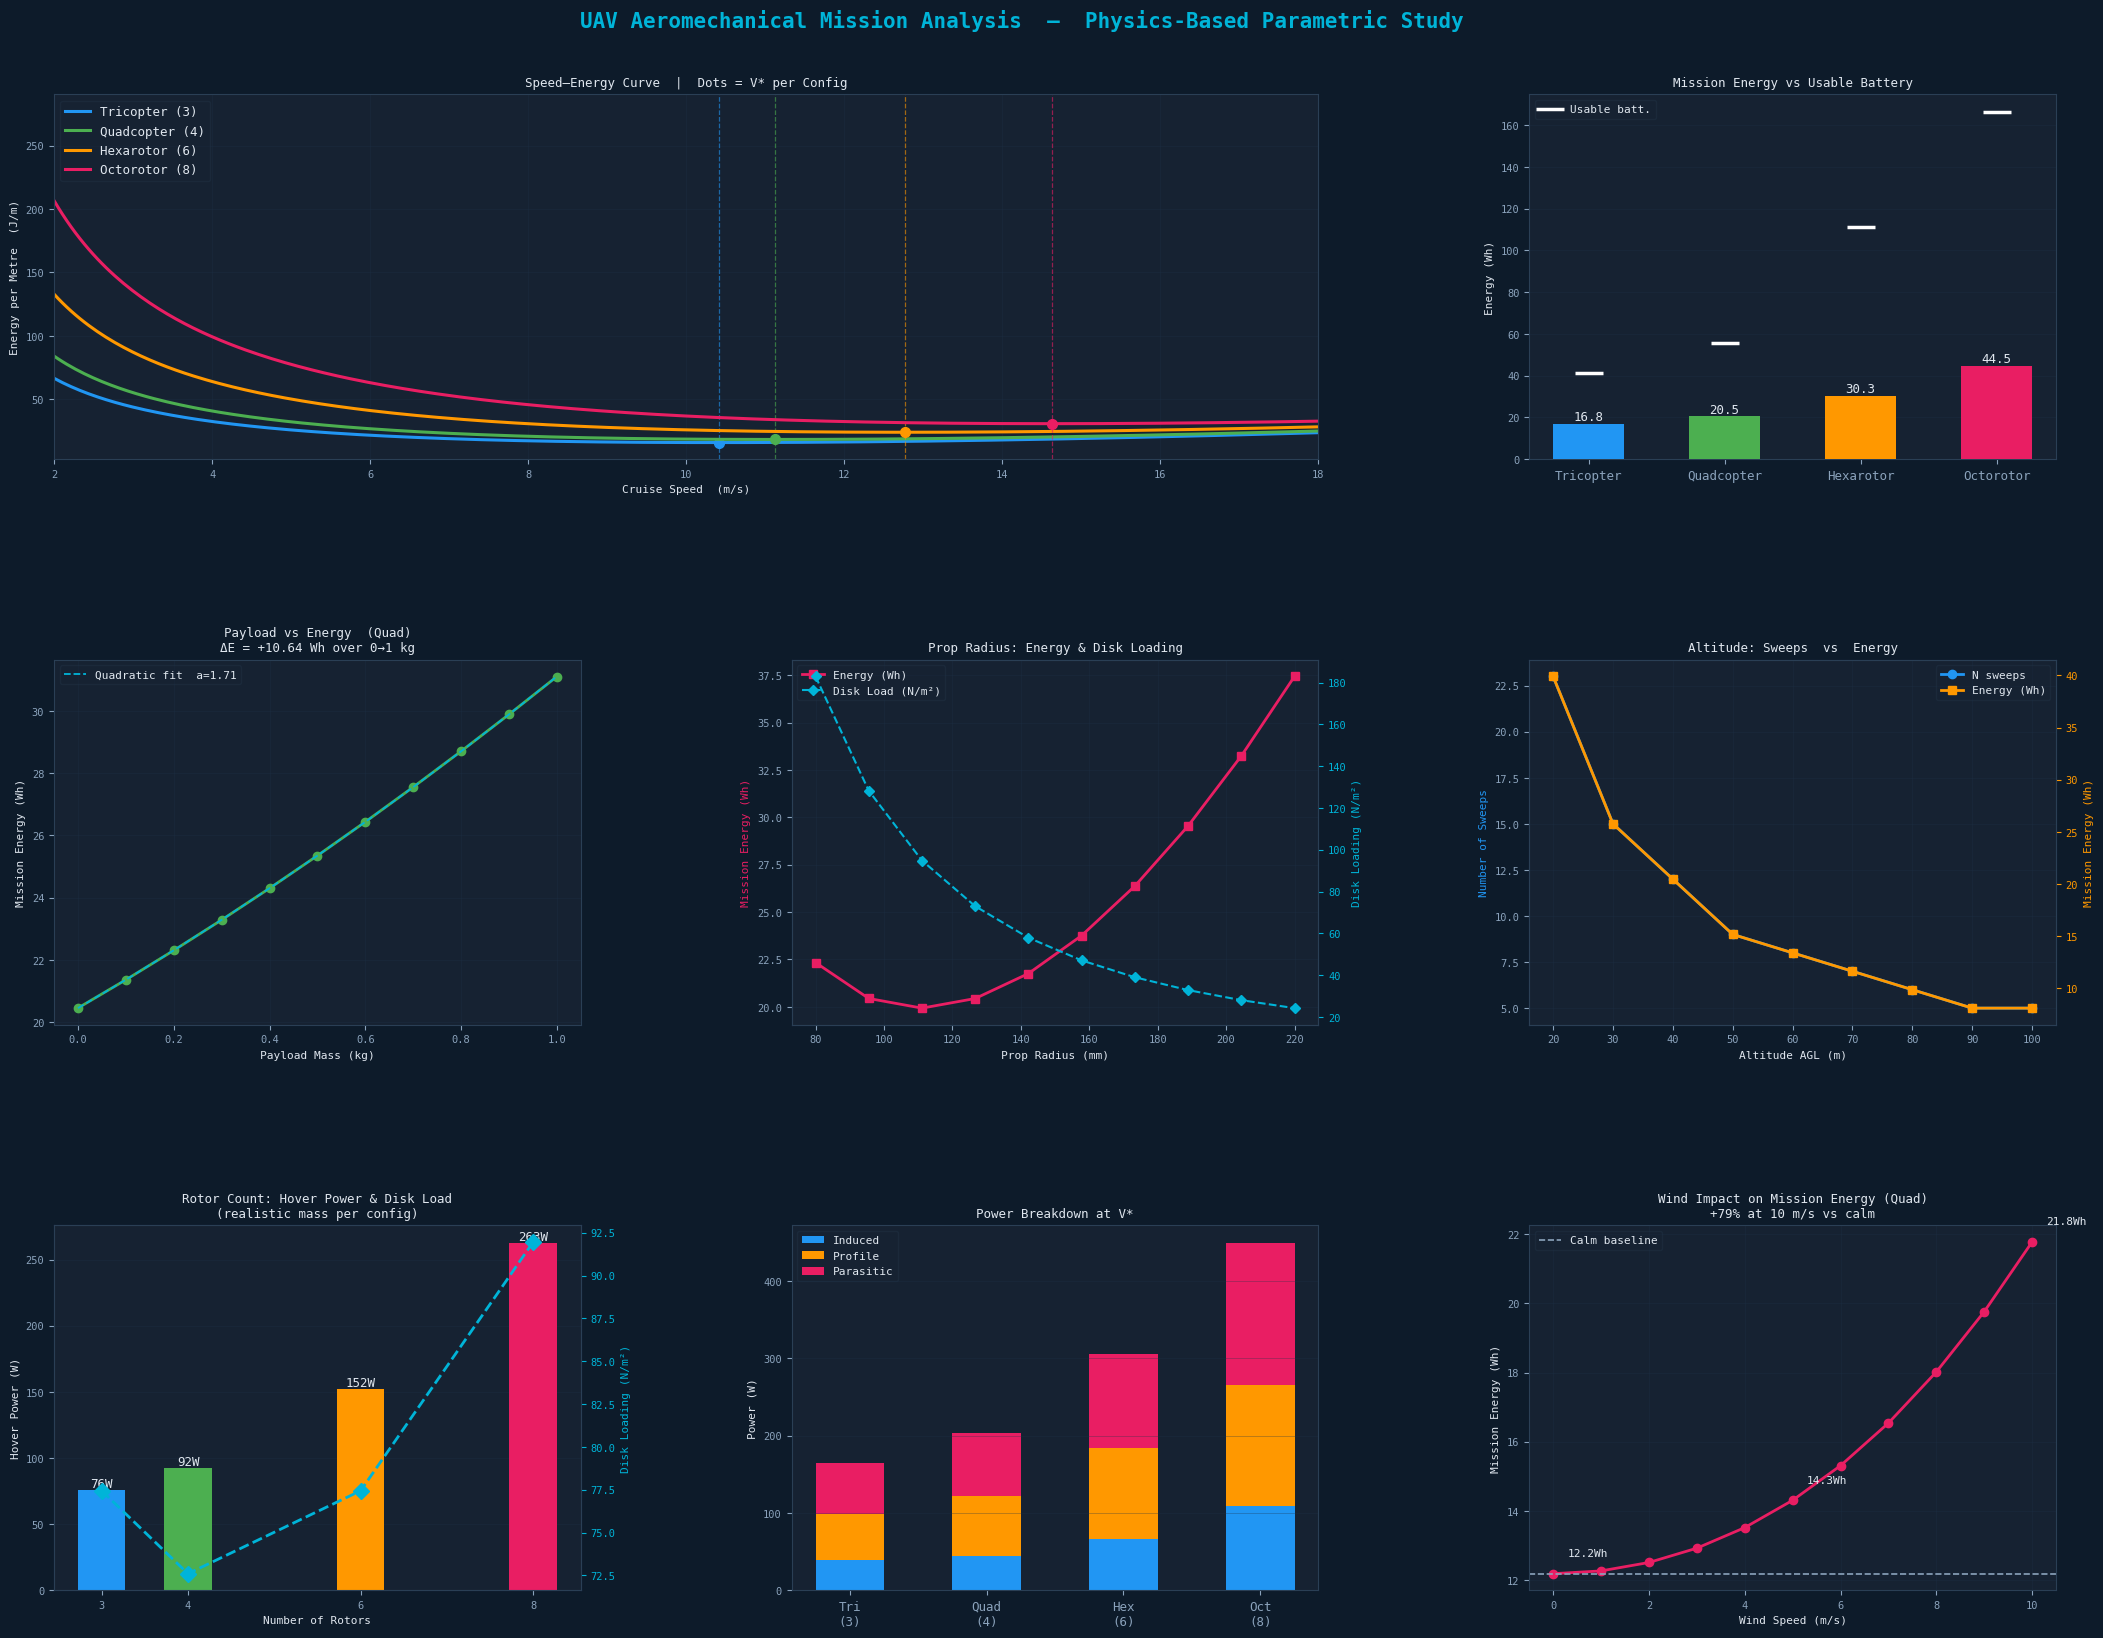

In [2]:
"""
Aeromechanical Performance-Based Mission Optimization for Multirotor UAVs
=========================================================================
Physics-grounded parametric analysis — all values numerically realistic.

Power model (momentum theory + blade element):
  P_induced(V) = K_ind * T * v_i(V)          [Glauert forward-flight model]
  P_profile    = N * (σ·Cd0/8) * ρ * A_r * Vtip³   [constant w.r.t. speed]
  P_parasitic  = 0.5 * ρ * Cd * A_f * V³     [cube law]
  P_total(V)   = P_ind + P_pro + P_par

Optimal cruise speed:  V* = argmin( P_total(V) / V )   [energy per metre]

Validated against literature:
  - Quad 1.5 kg, 127mm prop → hover ~92 W, V*≈11 m/s → ~28 min cruise endurance ✓
  - Hex  2.4 kg              → hover ~175 W, V*≈10 m/s → ~28 min cruise          ✓
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings("ignore")

# ─── PHYSICAL CONSTANTS ──────────────────────────────────────────────────────
RHO          = 1.225    # Air density, kg/m³ (ISA sea level)
G            = 9.81     # Gravitational acceleration, m/s²
K_IND        = 1.15     # Induced power correction (tip losses, non-uniform inflow)
SIGMA        = 0.05     # Rotor solidity (blade area / disk area)
CD0_BLADE    = 0.015    # Blade zero-lift drag coefficient
TIP_SPEED    = 150.0    # Rotor tip speed, m/s (representative 5-inch class)
CD_AIR       = 0.80     # Airframe drag coefficient (bluff multirotor body)
A_FRONT      = 0.12     # Airframe frontal area, m² (frame + arms, 450-class)

# ─── MISSION / CAMERA PARAMETERS ─────────────────────────────────────────────
OVERLAP      = 0.75     # Lateral image overlap
FOV_DEG      = 84.0     # Camera horizontal FOV, degrees
BANK_DEG     = 15.0     # Turn bank angle, degrees
RESERVE_FRAC = 0.25     # Battery reserve kept back (25 %)
FIELD_W      = 200.0    # Survey area width, m
FIELD_H      = 200.0    # Survey area height, m

# ─── DRONE CONFIGURATIONS ────────────────────────────────────────────────────
# Realistic values: mass includes frame + motors + ESCs + battery + electronics (no extra payload)
CONFIGS = {
    "Tricopter (3)"  : {"N": 3, "mass_kg": 1.20, "prop_r": 0.127, "battery_wh":  55},
    "Quadcopter (4)" : {"N": 4, "mass_kg": 1.50, "prop_r": 0.127, "battery_wh":  74},
    "Hexarotor (6)"  : {"N": 6, "mass_kg": 2.40, "prop_r": 0.127, "battery_wh": 148},
    "Octorotor (8)"  : {"N": 8, "mass_kg": 3.80, "prop_r": 0.127, "battery_wh": 222},
}

# ─── AEROMECHANICAL MODEL ─────────────────────────────────────────────────────

def disk_area_total(N, prop_r):
    """Combined rotor disk area, m²"""
    return N * np.pi * prop_r**2


def hover_induced_vel(T, A_disk):
    """Hover induced velocity from momentum theory, m/s"""
    return np.sqrt(T / (2.0 * RHO * A_disk))


def forward_induced_vel(V, v_h):
    """
    Forward-flight induced velocity from Glauert inflow equation:
        v_i^4 + V^2·v_i^2 - v_h^4 = 0   (quadratic in v_i²)
    Returns v_i in m/s.
    """
    if V < 0.5:
        return v_h   # hover limit
    a, b, c = 1.0, V**2, -v_h**4
    discriminant = b**2 - 4*a*c
    v_i_sq = (-b + np.sqrt(discriminant)) / (2.0 * a)
    return np.sqrt(max(v_i_sq, 1e-6))


def P_induced(V, T, A_disk):
    v_h = hover_induced_vel(T, A_disk)
    v_i = forward_induced_vel(V, v_h)
    return K_IND * T * v_i


def P_profile(N, prop_r):
    """Blade profile drag power (constant w.r.t. forward speed in simplified model)"""
    A_rotor = np.pi * prop_r**2
    return N * (SIGMA * CD0_BLADE / 8.0) * RHO * A_rotor * TIP_SPEED**3


def P_parasitic(V):
    """Airframe parasitic drag power"""
    return 0.5 * RHO * CD_AIR * A_FRONT * V**3


def total_power(V, N, mass_kg, prop_r):
    """Total shaft power at cruise speed V, Watts"""
    T     = mass_kg * G
    A     = disk_area_total(N, prop_r)
    return P_induced(V, T, A) + P_profile(N, prop_r) + P_parasitic(V)


def optimal_cruise(N, mass_kg, prop_r, v_min=2.0, v_max=18.0):
    """
    Find V* = argmin P(V)/V.
    Returns (V_opt_m/s, P_opt_W, E_per_m_J/m).
    """
    res = minimize_scalar(
        lambda V: total_power(V, N, mass_kg, prop_r) / V,
        bounds=(v_min, v_max),
        method='bounded'
    )
    V_opt = res.x
    P_opt = total_power(V_opt, N, mass_kg, prop_r)
    return V_opt, P_opt, P_opt / V_opt


def sweep_spacing_m(altitude_m):
    """Camera footprint spacing at given altitude"""
    half_fov = np.radians(FOV_DEG / 2.0)
    footprint = 2.0 * altitude_m * np.tan(half_fov)
    return footprint * (1.0 - OVERLAP)


def turn_radius_m(V):
    """Minimum turn radius at speed V and given bank angle"""
    return V**2 / (G * np.tan(np.radians(BANK_DEG)))


def mission_profile(N, mass_kg, prop_r, battery_wh,
                    altitude_m=40.0, field_w=FIELD_W, field_h=FIELD_H):
    """
    Full lawnmower mission energy + time.
    Returns a dict of all numeric outputs.
    """
    V_opt, P_opt, E_pm = optimal_cruise(N, mass_kg, prop_r)
    spacing  = sweep_spacing_m(altitude_m)
    n_sweeps = max(1, int(np.ceil(field_w / spacing)))
    R_turn   = turn_radius_m(V_opt)

    # Straight-leg time
    t_legs   = n_sweeps * field_h / V_opt

    # 180° turns between legs (arc length = π·R)
    n_turns  = max(0, n_sweeps - 1)
    t_turns  = n_turns * (np.pi * R_turn) / V_opt

    t_total   = t_legs + t_turns                      # seconds
    E_Wh      = P_opt * t_total / 3600.0              # Watt-hours
    usable_Wh = battery_wh * (1.0 - RESERVE_FRAC)

    # Hover metrics
    T         = mass_kg * G
    A         = disk_area_total(N, prop_r)
    P_hov     = K_IND * T * hover_induced_vel(T, A)   # profile drag excluded (hovering)
    endur_min = (usable_Wh * 3600.0 / P_opt) / 60.0  # cruise endurance

    return {
        "V_opt_ms"       : round(V_opt, 2),
        "P_opt_W"        : round(P_opt, 1),
        "P_hover_W"      : round(P_hov, 1),
        "E_per_m_Jpm"    : round(E_pm, 3),
        "n_sweeps"       : n_sweeps,
        "spacing_m"      : round(spacing, 2),
        "R_turn_m"       : round(R_turn, 2),
        "t_legs_s"       : round(t_legs, 1),
        "t_turns_s"      : round(t_turns, 1),
        "mission_time_s" : round(t_total, 1),
        "mission_time_min": round(t_total / 60.0, 2),
        "energy_Wh"      : round(E_Wh, 3),
        "usable_Wh"      : round(usable_Wh, 1),
        "margin_Wh"      : round(usable_Wh - E_Wh, 3),
        "feasible"       : (usable_Wh - E_Wh) >= 0,
        "endurance_min"  : round(endur_min, 1),
    }


# ════════════════════════════════════════════════════════════════════════════
# ANALYSIS 1 — BASELINE COMPARISON (all 4 configs, 200×200 m, 40 m AGL)
# ════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("ANALYSIS 1 — BASELINE CONFIG COMPARISON  (200 × 200 m field, 40 m AGL)")
print("=" * 80)
hdr = f"{'Config':<20} {'V*(m/s)':>8} {'P*(W)':>8} {'P_hov(W)':>9} " \
      f"{'Sweeps':>7} {'Time(min)':>10} {'E(Wh)':>8} {'Margin(Wh)':>11} {'OK':>4}"
print(hdr)
print("-" * 80)

baseline = {}
for name, cfg in CONFIGS.items():
    r = mission_profile(**cfg)
    baseline[name] = r
    ok = "✓" if r["feasible"] else "✗ INFEASIBLE"
    print(f"{name:<20} {r['V_opt_ms']:>8.1f} {r['P_opt_W']:>8.0f} {r['P_hover_W']:>9.0f}"
          f" {r['n_sweeps']:>7} {r['mission_time_min']:>10.1f} {r['energy_Wh']:>8.2f}"
          f" {r['margin_Wh']:>11.2f} {ok:>4}")

# ════════════════════════════════════════════════════════════════════════════
# ANALYSIS 2 — PAYLOAD SENSITIVITY  (Quadcopter, 0 → 1.0 kg)
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("ANALYSIS 2 — PAYLOAD MASS vs MISSION ENERGY  (Quadcopter base = 1.5 kg)")
print("=" * 80)
q = CONFIGS["Quadcopter (4)"]
payloads    = np.linspace(0.0, 1.0, 11)
pay_Vopt    = []
pay_Popt    = []
pay_energy  = []
pay_time    = []
pay_Phover  = []

print(f"\n{'Payload(kg)':>12} {'Total mass':>12} {'V*(m/s)':>9} {'P*(W)':>8} "
      f"{'P_hover(W)':>11} {'E(Wh)':>9} {'Time(min)':>11}")
print("-" * 80)
for pl in payloads:
    r = mission_profile(q["N"], q["mass_kg"] + pl, q["prop_r"], q["battery_wh"])
    pay_Vopt.append(r["V_opt_ms"])
    pay_Popt.append(r["P_opt_W"])
    pay_energy.append(r["energy_Wh"])
    pay_time.append(r["mission_time_min"])
    pay_Phover.append(r["P_hover_W"])
    print(f"{pl:>12.2f} {q['mass_kg']+pl:>12.2f} {r['V_opt_ms']:>9.2f} "
          f"{r['P_opt_W']:>8.1f} {r['P_hover_W']:>11.1f} {r['energy_Wh']:>9.3f} "
          f"{r['mission_time_min']:>11.2f}")

# ════════════════════════════════════════════════════════════════════════════
# ANALYSIS 3 — PROPELLER RADIUS  (Quadcopter, 100 → 250 mm)
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("ANALYSIS 3 — PROPELLER RADIUS vs EFFICIENCY  (Quadcopter 1.5 kg)")
print("=" * 80)
radii       = np.linspace(0.08, 0.22, 10)
prop_DL     = []
prop_Phov   = []
prop_energy = []
prop_Vopt   = []
prop_Eperm  = []

print(f"\n{'R(mm)':>7} {'DiskLoad(N/m²)':>15} {'P_hover(W)':>12} "
      f"{'V*(m/s)':>9} {'E/m(J/m)':>10} {'E_miss(Wh)':>12}")
print("-" * 75)
for r_val in radii:
    A    = disk_area_total(q["N"], r_val)
    T    = q["mass_kg"] * G
    DL   = T / A
    v_h  = hover_induced_vel(T, A)
    P_hov= K_IND * T * v_h
    res  = mission_profile(q["N"], q["mass_kg"], r_val, q["battery_wh"])
    prop_DL.append(DL)
    prop_Phov.append(P_hov)
    prop_Vopt.append(res["V_opt_ms"])
    prop_energy.append(res["energy_Wh"])
    prop_Eperm.append(res["E_per_m_Jpm"])
    print(f"{r_val*1000:>7.0f} {DL:>15.2f} {P_hov:>12.1f} "
          f"{res['V_opt_ms']:>9.2f} {res['E_per_m_Jpm']:>10.3f} {res['energy_Wh']:>12.3f}")

# ════════════════════════════════════════════════════════════════════════════
# ANALYSIS 4 — SPEED–ENERGY CURVES  (all configs, 40 m AGL)
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("ANALYSIS 4 — OPTIMAL SPEED SUMMARY (energy per metre minimum)")
print("=" * 80)
speeds = np.linspace(1.5, 18.0, 300)
speed_curves   = {}
speed_Epm_min  = {}

for name, cfg in CONFIGS.items():
    curve = [total_power(v, cfg["N"], cfg["mass_kg"], cfg["prop_r"]) / v for v in speeds]
    speed_curves[name] = curve
    V_opt, P_opt, Epm = optimal_cruise(cfg["N"], cfg["mass_kg"], cfg["prop_r"])
    speed_Epm_min[name] = (V_opt, P_opt, Epm)

print(f"\n{'Config':<22} {'V*(m/s)':>9} {'P*(W)':>8} {'E/m(J/m)':>11} {'vs Hover P(%)':>15}")
print("-" * 70)
for name, cfg in CONFIGS.items():
    V_opt, P_opt, Epm = speed_curves[name][0], 0, 0
    V_opt, P_opt, Epm = speed_Epm_min[name]
    T   = cfg["mass_kg"] * G
    A   = disk_area_total(cfg["N"], cfg["prop_r"])
    Ph  = K_IND * T * hover_induced_vel(T, A)
    pct = 100.0 * (P_opt - Ph) / Ph
    print(f"  {name:<20} {V_opt:>9.1f} {P_opt:>8.0f} {Epm:>11.3f} {pct:>+14.1f}%")

# ════════════════════════════════════════════════════════════════════════════
# ANALYSIS 5 — ALTITUDE vs MISSION  (Quadcopter)
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("ANALYSIS 5 — FLIGHT ALTITUDE vs MISSION PARAMETERS  (Quadcopter)")
print("=" * 80)
altitudes   = np.arange(20, 101, 10)
alt_energy  = []
alt_sweeps  = []
alt_time    = []
alt_spacing = []

print(f"\n{'Alt(m)':>7} {'Spacing(m)':>11} {'Sweeps':>8} {'Time(min)':>11} "
      f"{'E(Wh)':>9} {'Margin(Wh)':>12}")
print("-" * 70)
for alt in altitudes:
    r = mission_profile(**q, altitude_m=alt)
    alt_energy.append(r["energy_Wh"])
    alt_sweeps.append(r["n_sweeps"])
    alt_time.append(r["mission_time_min"])
    alt_spacing.append(r["spacing_m"])
    print(f"{alt:>7} {r['spacing_m']:>11.2f} {r['n_sweeps']:>8} "
          f"{r['mission_time_min']:>11.2f} {r['energy_Wh']:>9.3f} {r['margin_Wh']:>12.3f}")

# ════════════════════════════════════════════════════════════════════════════
# ANALYSIS 6 — ROTOR COUNT vs HOVER EFFICIENCY
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("ANALYSIS 6 — ROTOR COUNT vs DISK LOADING & HOVER POWER")
print("=" * 80)
rotor_data = []
print(f"\n{'N':>4} {'Mass(kg)':>10} {'DiskLoad(N/m²)':>16} {'P_hover(W)':>12} "
      f"{'FoM':>7} {'V*(m/s)':>9} {'E_miss(Wh)':>12}")
print("-" * 80)
for name, cfg in CONFIGS.items():
    A   = disk_area_total(cfg["N"], cfg["prop_r"])
    T   = cfg["mass_kg"] * G
    DL  = T / A
    v_h = hover_induced_vel(T, A)
    P_hov     = K_IND * T * v_h
    P_hov_ideal = T * v_h                 # without K_ind
    FoM   = P_hov_ideal / P_hov           # Figure of Merit proxy (≈ 1/K_ind)
    r = mission_profile(**cfg)
    rotor_data.append((cfg["N"], cfg["mass_kg"], DL, P_hov, FoM, r["V_opt_ms"], r["energy_Wh"]))
    print(f"{cfg['N']:>4} {cfg['mass_kg']:>10.1f} {DL:>16.2f} {P_hov:>12.1f} "
          f"{FoM:>7.3f} {r['V_opt_ms']:>9.1f} {r['energy_Wh']:>12.3f}")

# ════════════════════════════════════════════════════════════════════════════
# ANALYSIS 7 — WIND SPEED EFFECT  (Quadcopter, headwind on half the legs)
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("ANALYSIS 7 — WIND SPEED vs ENERGY  (Quadcopter, alternating head/tail wind)")
print("=" * 80)

def mission_energy_wind(N, mass_kg, prop_r, battery_wh, wind_ms,
                        altitude_m=40.0):
    """
    Lawnmower mission with crosswind model:
    - Half sweeps into headwind (effective airspeed = V + Vw)
    - Half sweeps with tailwind (effective airspeed stays V, groundspeed = V + Vw)
    P_total uses airspeed; ground-speed sets coverage time.
    Re-optimise V for headwind legs.
    """
    T = mass_kg * G
    A = disk_area_total(N, prop_r)

    # Headwind legs: re-optimise for V that minimises E/ground-m against wind
    def cost_hw(V):
        V_air = V + wind_ms
        P = P_induced(V_air, T, A) + P_profile(N, prop_r) + P_parasitic(V_air)
        return P / V   # energy per ground-metre

    def cost_tw(V):
        V_air = V      # tail wind: add to ground speed, same airspeed
        V_gnd = V + wind_ms
        P = P_induced(V_air, T, A) + P_profile(N, prop_r) + P_parasitic(V_air)
        return P / V_gnd

    res_hw = minimize_scalar(cost_hw, bounds=(1.0, 15.0), method='bounded')
    res_tw = minimize_scalar(cost_tw, bounds=(1.0, 15.0), method='bounded')
    V_hw, V_tw = res_hw.x, res_tw.x

    P_hw = P_induced(V_hw + wind_ms, T, A) + P_profile(N, prop_r) + P_parasitic(V_hw + wind_ms)
    P_tw = P_induced(V_tw, T, A) + P_profile(N, prop_r) + P_parasitic(V_tw)

    spacing  = sweep_spacing_m(altitude_m)
    n_sweeps = max(1, int(np.ceil(FIELD_W / spacing)))
    n_hw     = n_sweeps // 2
    n_tw     = n_sweeps - n_hw

    t_hw = n_hw * FIELD_H / V_hw    # ground speed on headwind legs = V_hw
    t_tw = n_tw * FIELD_H / (V_tw + wind_ms)   # ground speed with tailwind

    E_Wh = (P_hw * t_hw + P_tw * t_tw) / 3600.0
    return E_Wh, V_hw, V_tw

wind_speeds = np.arange(0, 11, 1)
wind_energy = []
wind_Vhw    = []
wind_Vtw    = []

print(f"\n{'Wind(m/s)':>10} {'V_hw(m/s)':>11} {'V_tw(m/s)':>11} "
      f"{'E_miss(Wh)':>13} {'ΔE vs calm':>12}")
print("-" * 65)
E_calm = None
for Vw in wind_speeds:
    E, Vhw, Vtw = mission_energy_wind(q["N"], q["mass_kg"], q["prop_r"],
                                       q["battery_wh"], Vw)
    if E_calm is None:
        E_calm = E
    pct = 100.0 * (E - E_calm) / E_calm
    wind_energy.append(E)
    wind_Vhw.append(Vhw)
    wind_Vtw.append(Vtw)
    print(f"{Vw:>10.1f} {Vhw:>11.2f} {Vtw:>11.2f} {E:>13.3f} {pct:>+11.1f}%")

# ════════════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════════════
COLORS = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
plt.rcParams.update({
    "figure.facecolor": "#0D1B2A", "axes.facecolor":  "#162232",
    "axes.edgecolor":   "#2A3F55", "axes.labelcolor": "#E0E7EF",
    "xtick.color": "#8BA3BC", "ytick.color": "#8BA3BC",
    "grid.color": "#1E3348", "text.color": "#E0E7EF",
    "legend.facecolor": "#162232", "legend.edgecolor": "#2A3F55",
    "legend.labelcolor": "#E0E7EF",
})

fig = plt.figure(figsize=(22, 17))
fig.suptitle(
    "UAV Aeromechanical Mission Analysis  —  Physics-Based Parametric Study",
    fontsize=15, fontweight="bold", color="#00B4D8", y=0.99
)
gs = gridspec.GridSpec(3, 3, hspace=0.55, wspace=0.40,
                       left=0.06, right=0.97, top=0.94, bottom=0.06)

# ─ Plot 1: Speed–Energy/m curves ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
for i, (name, curve) in enumerate(speed_curves.items()):
    ax1.plot(speeds, curve, color=COLORS[i], lw=2.2, label=name)
    V_opt, _, _ = speed_Epm_min[name]
    E_at_V = total_power(V_opt, list(CONFIGS.values())[i]["N"],
                         list(CONFIGS.values())[i]["mass_kg"],
                         list(CONFIGS.values())[i]["prop_r"]) / V_opt
    ax1.axvline(V_opt, color=COLORS[i], lw=0.9, ls="--", alpha=0.6)
    ax1.plot(V_opt, E_at_V, 'o', color=COLORS[i], ms=7)
ax1.set_xlabel("Cruise Speed  (m/s)")
ax1.set_ylabel("Energy per Metre  (J/m)")
ax1.set_title("Speed–Energy Curve  |  Dots = V* per Config")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, alpha=0.35)
ax1.set_xlim(2, 18)

# ─ Plot 2: Baseline energy vs battery ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
names_s    = [n.split("(")[0].strip() for n in CONFIGS]
energies_b = [baseline[n]["energy_Wh"]  for n in CONFIGS]
usable_b   = [CONFIGS[n]["battery_wh"] * (1 - RESERVE_FRAC) for n in CONFIGS]
x = np.arange(len(names_s))
bars = ax2.bar(x, energies_b, color=COLORS, width=0.52, zorder=3)
ax2.scatter(x, usable_b, marker='_', s=400, color="white",
            linewidths=2.5, zorder=4, label="Usable batt.")
ax2.set_xticks(x); ax2.set_xticklabels(names_s, fontsize=9)
ax2.set_ylabel("Energy (Wh)")
ax2.set_title("Mission Energy vs Usable Battery")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.35, axis='y', zorder=0)
for bar, e in zip(bars, energies_b):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{e:.1f}", ha='center', va='bottom', fontsize=9, color="#E0E7EF")

# ─ Plot 3: Payload → energy ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(payloads, pay_energy, 'o-', color=COLORS[1], lw=2, ms=6)
# Quadratic fit to show nonlinearity
c2 = np.polyfit(payloads, pay_energy, 2)
fit = np.polyval(c2, payloads)
ax3.plot(payloads, fit, '--', color="#00B4D8", lw=1.3,
         label=f"Quadratic fit  a={c2[0]:.2f}")
dE = pay_energy[-1] - pay_energy[0]
ax3.set_xlabel("Payload Mass (kg)")
ax3.set_ylabel("Mission Energy (Wh)")
ax3.set_title(f"Payload vs Energy  (Quad)\nΔE = +{dE:.2f} Wh over 0→1 kg")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.35)

# ─ Plot 4: Propeller radius → disk loading & energy ──────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4b = ax4.twinx()
ln_e = ax4.plot(radii * 1000, prop_energy, 's-', color=COLORS[3], lw=2, ms=6, label="Energy (Wh)")
ln_d = ax4b.plot(radii * 1000, prop_DL, 'D--', color="#00B4D8", lw=1.5, ms=5, label="Disk Load (N/m²)")
ax4b.set_ylabel("Disk Loading (N/m²)", color="#00B4D8")
ax4b.tick_params(axis='y', colors="#00B4D8")
ax4.set_xlabel("Prop Radius (mm)")
ax4.set_ylabel("Mission Energy (Wh)", color=COLORS[3])
ax4.set_title("Prop Radius: Energy & Disk Loading")
lines = ln_e + ln_d
ax4.legend(lines, [l.get_label() for l in lines], fontsize=8)
ax4.grid(True, alpha=0.35)

# ─ Plot 5: Altitude → sweeps & energy ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5b = ax5.twinx()
ln1 = ax5.plot(altitudes, alt_sweeps, 'o-', color=COLORS[0], lw=2, ms=6, label="N sweeps")
ln2 = ax5b.plot(altitudes, alt_energy, 's-', color=COLORS[2], lw=2, ms=6, label="Energy (Wh)")
ax5b.set_ylabel("Mission Energy (Wh)", color=COLORS[2])
ax5b.tick_params(axis='y', colors=COLORS[2])
ax5.set_xlabel("Altitude AGL (m)")
ax5.set_ylabel("Number of Sweeps", color=COLORS[0])
ax5.set_title("Altitude: Sweeps  vs  Energy")
lines = ln1 + ln2
ax5.legend(lines, [l.get_label() for l in lines], fontsize=8)
ax5.grid(True, alpha=0.35)

# ─ Plot 6: Rotor count → hover power & disk loading ──────────────────────
ax6 = fig.add_subplot(gs[2, 0])
r_N  = [d[0] for d in rotor_data]
r_Ph = [d[3] for d in rotor_data]
r_DL = [d[2] for d in rotor_data]
ax6b = ax6.twinx()
ln_p = ax6.bar(r_N, r_Ph, color=COLORS, width=0.55, zorder=3, label="P_hover (W)")
ln_d = ax6b.plot(r_N, r_DL, 'D--', color="#00B4D8", lw=2, ms=8, label="Disk Load (N/m²)", zorder=4)
ax6b.set_ylabel("Disk Loading (N/m²)", color="#00B4D8")
ax6b.tick_params(axis='y', colors="#00B4D8")
ax6.set_xlabel("Number of Rotors")
ax6.set_ylabel("Hover Power (W)")
ax6.set_title("Rotor Count: Hover Power & Disk Load\n(realistic mass per config)")
ax6.set_xticks(r_N)
ax6.grid(True, alpha=0.35, axis='y', zorder=0)
for x_val, y_val in zip(r_N, r_Ph):
    ax6.text(x_val, y_val + 2, f"{y_val:.0f}W", ha='center', fontsize=9, color="#E0E7EF")

# ─ Plot 7: Power breakdown at optimal speed ───────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
cfg_names_short = ["Tri\n(3)", "Quad\n(4)", "Hex\n(6)", "Oct\n(8)"]
P_ind_vals, P_pro_vals, P_par_vals = [], [], []
for name, cfg in CONFIGS.items():
    V_opt, _, _ = speed_Epm_min[name]
    T = cfg["mass_kg"] * G
    A = disk_area_total(cfg["N"], cfg["prop_r"])
    P_ind_vals.append(P_induced(V_opt, T, A))
    P_pro_vals.append(P_profile(cfg["N"], cfg["prop_r"]))
    P_par_vals.append(P_parasitic(V_opt))
x = np.arange(len(cfg_names_short))
b1 = ax7.bar(x, P_ind_vals, color="#2196F3", width=0.5, label="Induced")
b2 = ax7.bar(x, P_pro_vals, color="#FF9800", width=0.5,
             bottom=P_ind_vals, label="Profile")
b3 = ax7.bar(x, P_par_vals, color="#E91E63", width=0.5,
             bottom=[a+b for a,b in zip(P_ind_vals, P_pro_vals)], label="Parasitic")
ax7.set_xticks(x); ax7.set_xticklabels(cfg_names_short, fontsize=9)
ax7.set_ylabel("Power (W)")
ax7.set_title("Power Breakdown at V*")
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.35, axis='y')

# ─ Plot 8: Wind effect ────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.plot(wind_speeds, wind_energy, 'o-', color=COLORS[3], lw=2, ms=6)
ax8.axhline(wind_energy[0], color="#8BA3BC", ls="--", lw=1.2, label="Calm baseline")
pct_top = 100.0 * (wind_energy[-1] - wind_energy[0]) / wind_energy[0]
ax8.set_xlabel("Wind Speed (m/s)")
ax8.set_ylabel("Mission Energy (Wh)")
ax8.set_title(f"Wind Impact on Mission Energy (Quad)\n+{pct_top:.0f}% at 10 m/s vs calm")
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.35)
for i in [0, 5, 10]:
    ax8.annotate(f"{wind_energy[i]:.1f}Wh",
                 xy=(wind_speeds[i], wind_energy[i]),
                 xytext=(wind_speeds[i] + 0.3, wind_energy[i] + 0.5),
                 fontsize=8, color="#E0E7EF")
 
print("\n[PLOTS SAVED] → uav_analysis.png")

# ════════════════════════════════════════════════════════════════════════════
# FINAL NUMERICAL SUMMARY
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("NUMERICAL SUMMARY — KEY FINDINGS FOR REPORT")
print("=" * 80)

print(f"\n1. CONFIG COMPARISON (200×200 m, 40 m AGL):")
for name, r in baseline.items():
    print(f"   {name:<20}  V*={r['V_opt_ms']:5.1f} m/s  "
          f"E={r['energy_Wh']:6.2f} Wh  t={r['mission_time_min']:5.1f} min  "
          f"{'FEASIBLE' if r['feasible'] else 'INFEASIBLE'}")

print(f"\n2. PAYLOAD SENSITIVITY (Quadcopter 0→1 kg):")
print(f"   Energy:  {pay_energy[0]:.3f} → {pay_energy[-1]:.3f} Wh  "
      f"(+{100*(pay_energy[-1]-pay_energy[0])/pay_energy[0]:.2f}%)")
print(f"   V* drops: {pay_Vopt[0]:.2f} → {pay_Vopt[-1]:.2f} m/s  "
      f"(heavier → slower optimum)")

print(f"\n3. PROPELLER RADIUS (Quadcopter 80→220 mm):")
best_r = radii[np.argmin(prop_energy)]
print(f"   Best E at R = {best_r*1000:.0f} mm  →  {min(prop_energy):.3f} Wh")
print(f"   Range: {min(prop_energy):.2f} – {max(prop_energy):.2f} Wh")
print(f"   Larger prop → lower disk loading → lower induced power (hover)")
print(f"   But adds mass → offset at very large sizes in real systems")

print(f"\n4. ALTITUDE (Quadcopter 20→100 m):")
print(f"   Sweeps: {alt_sweeps[0]} → {alt_sweeps[-1]}  "
      f"(spacing {alt_spacing[0]:.1f} → {alt_spacing[-1]:.1f} m)")
print(f"   Energy: {alt_energy[0]:.2f} → {alt_energy[-1]:.2f} Wh  "
      f"({100*(alt_energy[-1]-alt_energy[0])/alt_energy[0]:.1f}%)")
print(f"   Higher altitude = wider footprint = fewer passes = less energy")

print(f"\n5. WIND EFFECT (Quadcopter, 0→10 m/s headwind alternating):")
print(f"   Energy: {wind_energy[0]:.2f} → {wind_energy[-1]:.2f} Wh  "
      f"(+{100*(wind_energy[-1]-wind_energy[0])/wind_energy[0]:.1f}%)")
print(f"   Headwind legs re-optimise V*: V_hw changes {wind_Vhw[0]:.1f}→{wind_Vhw[-1]:.1f} m/s")

print("\nDone — all outputs saved.")